<a href="https://colab.research.google.com/github/samvita0924/aiml-assignment/blob/main/linearregression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Churn_Modelling.csv to Churn_Modelling.csv
MSE: 0.1392325016289797
R2 Score: 0.14722413901546516


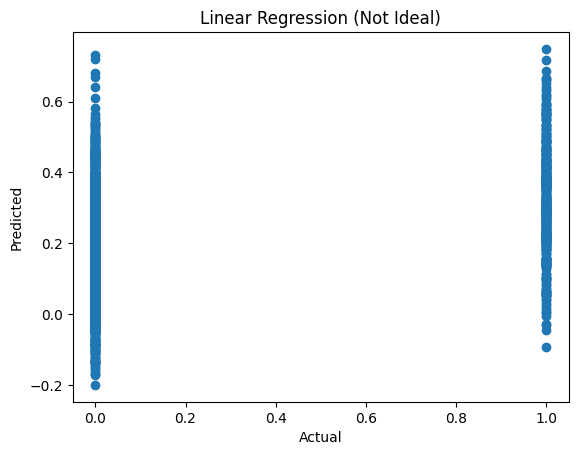

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from google.colab import files
uploaded = files.upload()
# Load
df = pd.read_csv("Churn_Modelling.csv")

# Drop unwanted columns
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# Encode
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

# Split
X = df.drop(columns=['Exited'])
y = df['Exited']

# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Convert continuous → binary
y_pred_binary = (y_pred > 0.5).astype(int)

# Metrics
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# Plot
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression (Not Ideal)")
plt.show()